# Tutorial 5: Checking Constraints (``module_constraint_checker``)

This tutorial demonstrates how to use the ``ConstraintChecker`` class to evaluate whether a turbine and vessel configuration satisfies key design constraints.

The constraints checked are:

1. **Power constraint**: electrical power should be nonnegative and should not exceed rated power.
2. **Depth constraint**: the rotor should remain submerged.
3. **Cavitation constraint**: estimated blade pressure should remain above vapor pressure.
4. **Pitch constraint**: simplified vessel pitch-stability margin should remain positive.

This tutorial briefly repeats the tidal-data, rotor-data, and rotor-simulation setup from previous tutorials so that the constraint-checking workflow is self-contained.

## Notes for new users

- Constraint checks return ``True`` only if the constraint is satisfied for all time steps.
- A constraint can fail at only one time step and still return ``False``.
- The constraint margins are useful because they show how close a design is to violating a constraint.
- Positive depth, cavitation, and pitch margins indicate feasible operation.
- The power constraint is satisfied when $0 \leq P_{elec} \leq P_{rated}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import urllib3

from vital.module_tidal import process_tidal_data
from vital.module_rotor import RotorData
from vital.module_rotor_simulation import RotorSimulation
from vital.module_vessel import VesselData
from vital.module_constraint_checker import ConstraintChecker

# Suppress warnings caused by NOAA requests using verify=False internally.
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

## 1. Load tidal and rotor data

First, load the tidal resource data and rotor performance data.

This tutorial uses the same basic NOAA workflow and Sitkana rotor file used in the previous tutorials.

In [2]:
# Tidal data inputs
station = "COI0303"
startdate = "2021-09-01"

range_hrs = 2 * 7 * 24
time_step_s = 3600
city_data_file = "../data/AlaskaCityLatLong.txt"

tidal = process_tidal_data(
    station=station,
    startdate=startdate,
    range_hrs=range_hrs,
    time_step_s=time_step_s,
    city_data_file=city_data_file,
)

print(f"Data source: {tidal.source}")
print(f"Station name: {tidal.station_name}")
print(f"Mooring distance: {tidal.mooring_distance:.2f} m")
print(f"Number of time points: {len(tidal.times)}")

# Rotor data
rotor_performance_file = "../data/Sitkana_rotor_data_blade_2.txt"
rotor = RotorData(rotor_performance_file)

print()
print(f"Optimal Cp: {rotor.CpOpt:.4f}")
print(f"Optimal TSR: {rotor.TSROpt:.4f}")
print(f"Estimated TSRmax: {rotor.TSRmax:.4f}")

Data source: NOAA
Station name: Port Mackenzie, South of
Mooring distance: 31.10 m
Number of time points: 336

Optimal Cp: 0.2119
Optimal TSR: 0.7648
Estimated TSRmax: 1.7084


## 2. Run rotor simulation

Next, define a turbine configuration and run ``RotorSimulation``.

The simulation results provide time histories for electrical power, rotor speed, thrust force, tip-speed ratio, and other quantities needed by the constraint checker.

In [3]:
config = {
    "Radius": 0.5,                    # Rotor radius (m)
    "Prated": 1000.0,                 # Rated electrical power (W)
    "Trated": 100.0,                  # Rated generator torque (N m)
    "dHub": 7.0,                      # Hub depth (m)
    "number_of_turbines": 2,          # Number of turbines

    # Site/time inputs
    "dMoor": tidal.mooring_distance,
    "Uinf": tidal.flow_speeds,
    "t": tidal.times,

    # Rotor performance functions
    "CpFunc": rotor.get_cp,
    "CqFunc": rotor.get_cq,
    "CtFunc": rotor.get_ct,
    "CpOpt": rotor.CpOpt,
    "TSROpt": rotor.TSROpt,
    "TSRmax": rotor.TSRmax,

    # Drivetrain and generator parameters
    "Ng": 10,
    "Kt": 1.5,
    "Rw": 0.5,
    "J_d": 10.0,
    "B_d": 1.0,
    "J_r": 50.0,

    # Power-conversion model
    "power_model": "simple",
}

rotor_sim = RotorSimulation(config)
rotor_sim.simulate()
result = rotor_sim.get_results()

print("Rotor simulation complete.")
print(f"Maximum electrical power: {np.max(result['Pelec']) / 1000:.3f} kW")
print(f"Rated electrical power: {config['Prated'] / 1000:.3f} kW")
print(f"Maximum thrust force: {np.max(result['Ft']):.3f} N")

Solving the initial value problem (IVP) for turbine dynamics...


IVP solving complete.
Rotor simulation complete.
Maximum electrical power: 0.745 kW
Rated electrical power: 1.000 kW
Maximum thrust force: 2803.044 N


## 3. Define vessel properties

The pitch constraint requires vessel/platform properties such as pitch stiffness, mooring angle, projected area, and force-application locations.

For this tutorial, we use a simple representative vessel configuration. These values are for demonstration only and should be replaced with project-specific vessel or platform properties for design studies.

In [4]:
user_vessel_properties = {
    "Xm": 5.77,                       # Horizontal distance from center of rotation (m)
    "Zm": 1.65,                       # Vertical distance from center of rotation (m)
    "Kphi": 1.95e6,                   # Pitch hydrostatic stiffness (N m/rad)
    "theta": 45.0 * np.pi / 180.0,    # Mooring line angle (rad)
    "phi": 10.0 * np.pi / 180.0,      # Allowable/representative pitch angle (rad)
    "area": 9.5,                      # Cross-sectional area (m^2)
    "Cd": 1.0,                        # Drag coefficient
}

vessel = VesselData(
    user_defined=True,
    vessel_properties=user_vessel_properties,
    simResult=result,
)

print("Vessel properties used for constraint checking:")
print(f"  Xm: {vessel.Xm:.3f} m")
print(f"  Zm: {vessel.Zm:.3f} m")
print(f"  Kphi: {vessel.Kphi:.3e} N m/rad")
print(f"  theta_m: {vessel.theta_m:.3f} rad")
print(f"  phi: {vessel.phi:.3f} rad")
print(f"  area: {vessel.area:.3f} m^2")
print(f"  Cd: {vessel.Cd:.3f}")

if vessel.Fdrag is not None:
    print(f"  Maximum vessel drag: {np.max(vessel.Fdrag):.3f} N")

Vessel properties used for constraint checking:
  Xm: 5.770 m
  Zm: 1.650 m
  Kphi: 1.950e+06 N m/rad
  theta_m: 0.785 rad
  phi: 0.175 rad
  area: 9.500 m^2
  Cd: 1.000
  Maximum vessel drag: 43473.266 N


## 4. Check constraints

Now initialize ``ConstraintChecker`` and evaluate each constraint.

Each check returns a Boolean value:

- ``True``: the constraint is satisfied for all time steps.
- ``False``: the constraint is violated for at least one time step.

In [5]:
constraint_checker = ConstraintChecker(rotor, config, vessel, result)

constraints = {
    "Power Constraint": constraint_checker.check_power_constraint(),
    "Depth Constraint": constraint_checker.check_depth_constraint(),
    "Cavitation Constraint": constraint_checker.check_cavitation_constraint(),
    "Pitch Constraint": constraint_checker.check_pitch_constraint(),
}

print("Constraint Results:")
for name, satisfied in constraints.items():
    status = "Satisfied" if satisfied else "Not Satisfied"
    print(f"  {name}: {status}")

if all(constraints.values()):
    print("\nAll constraints are satisfied.")
else:
    print("\nOne or more constraints are not satisfied.")

Constraint Results:
  Power Constraint: Satisfied
  Depth Constraint: Satisfied
  Cavitation Constraint: Satisfied
  Pitch Constraint: Satisfied

All constraints are satisfied.


## 5. Inspect constraint margins

The Boolean checks are useful, but margins provide more information.

The margin conventions used here are:

- Power margin: $P_{rated} - P_{elec}$. This should be nonnegative.
- Depth margin: $d_{hub} - R$. This should be positive.
- Cavitation margin: should be positive.
- Pitch margin: should be positive.

The minimum margin over time is often the most important value.

In [6]:
power_margin = constraint_checker.power_constraint()
depth_margin = constraint_checker.depth_constraint()
cavitation_margin = constraint_checker.cavitation_constraint()
pitch_margin = constraint_checker.pitch_constraint()

print("Constraint margins:")
print(f"  Minimum power margin, Prated - Pelec: {np.min(power_margin):.3f} W")
print(f"  Depth margin, dHub - Radius: {depth_margin:.3f} m")
print(f"  Minimum cavitation margin: {np.min(cavitation_margin):.3f} Pa")
print(f"  Minimum pitch margin: {np.min(pitch_margin):.3f} N m")

print()
print("Additional power checks:")
print(f"  Minimum Pelec: {np.min(result['Pelec']):.3f} W")
print(f"  Maximum Pelec: {np.max(result['Pelec']):.3f} W")
print(f"  Rated power: {config['Prated']:.3f} W")

Constraint margins:
  Minimum power margin, Prated - Pelec: 254.999 W
  Depth margin, dHub - Radius: 6.500 m
  Minimum cavitation margin: 157528.652 Pa
  Minimum pitch margin: 43590.347 N m

Additional power checks:
  Minimum Pelec: 0.000 W
  Maximum Pelec: 745.001 W
  Rated power: 1000.000 W


## 6. Plot constraint margins

The plots below show the time-varying constraint margins.

For the plotted constraints, values below zero indicate a violation.

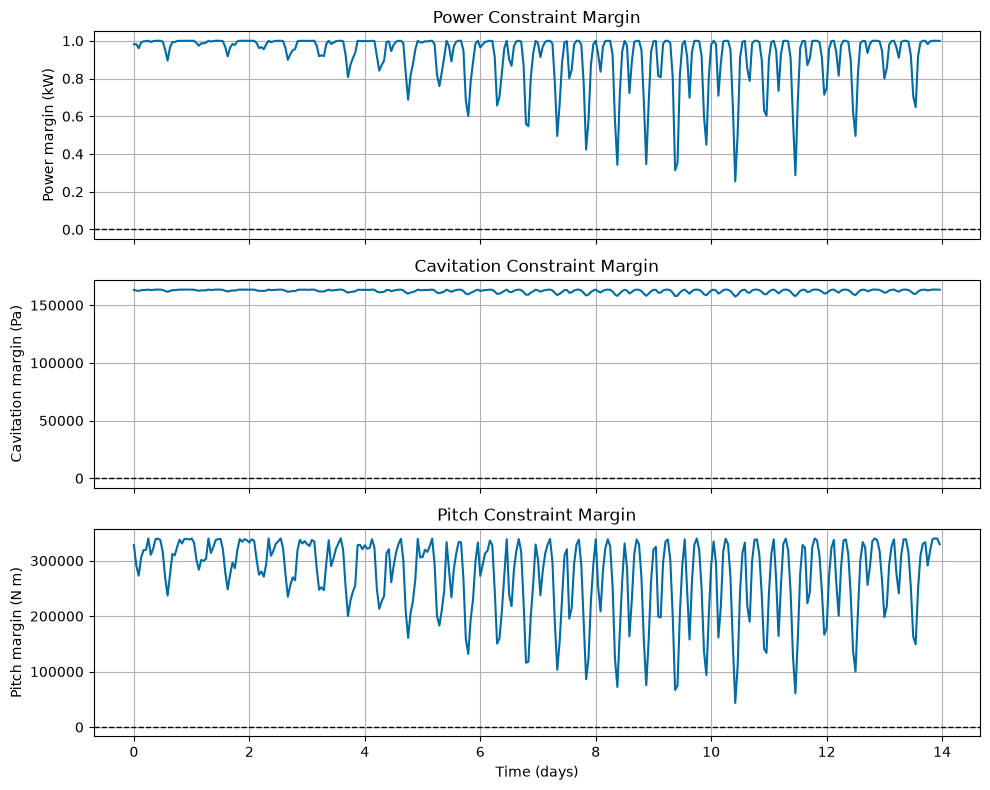

Depth margin is constant for this simulation: 6.500 m


In [7]:
time_days = result["t"] / (3600 * 24)

fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

# Power margin
ax[0].plot(time_days, power_margin / 1000)
ax[0].axhline(0.0, color="k", linestyle="--", linewidth=1)
ax[0].set_ylabel("Power margin (kW)")
ax[0].set_title("Power Constraint Margin")
ax[0].grid(True)

# Cavitation margin
ax[1].plot(time_days, cavitation_margin)
ax[1].axhline(0.0, color="k", linestyle="--", linewidth=1)
ax[1].set_ylabel("Cavitation margin (Pa)")
ax[1].set_title("Cavitation Constraint Margin")
ax[1].grid(True)

# Pitch margin
ax[2].plot(time_days, pitch_margin)
ax[2].axhline(0.0, color="k", linestyle="--", linewidth=1)
ax[2].set_ylabel("Pitch margin (N m)")
ax[2].set_xlabel("Time (days)")
ax[2].set_title("Pitch Constraint Margin")
ax[2].grid(True)

plt.tight_layout()
plt.show()

print(f"Depth margin is constant for this simulation: {depth_margin:.3f} m")

## Summary

This tutorial showed how to:

- Load tidal and rotor data.
- Run a rotor simulation.
- Define vessel properties.
- Check power, depth, cavitation, and pitch constraints.
- Inspect and plot constraint margins.

The next tutorial uses the same type of simulation output to estimate levelized cost of energy.